# Skin Cancer ISIC Classifier — Model Development Notebook

This notebook loads the ISIC skin lesion dataset, builds a MobileNetV2 transfer-learning
model, trains it in two phases, evaluates it, and tests single-image prediction.


In [ ]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_PATH = '/content/drive/MyDrive/skin_cancer_classifier'

print("Contents of project folder:")
print(os.listdir(PROJECT_PATH))
print("\nContents of data/train:")
print(os.listdir(os.path.join(PROJECT_PATH, 'data', 'train')))

Contents of project folder:
['app.py', 'locustfile.py', 'data', 'src', 'models']

Contents of data/train:
['vascular lesion', 'squamous cell carcinoma', 'seborrheic keratosis', 'melanoma', 'dermatofibroma', 'nevus', 'pigmented benign keratosis', 'basal cell carcinoma', 'actinic keratosis']


In [ ]:
import sys
sys.path.append(PROJECT_PATH)

from src.preprocessing import load_datasets, IMG_SIZE, CLASS_NAMES
from src.model import (
    build_model,
    compile_model,
    train_model,
    fine_tune_model,
    evaluate_model,
    save_model,
)

print("Classes:", CLASS_NAMES)
print("Number of classes:", len(CLASS_NAMES))

Classes: ['actinic_keratosis', 'basal_cell_carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented_benign_keratosis', 'seborrheic_keratosis', 'squamous_cell_carcinoma', 'vascular_lesion']
Number of classes: 9


## Loading the data

We're working with 9 skin lesion classes from the ISIC dataset. The cell below loads
`data/train` (split 80/20 into training and validation) and `data/test`, resizing every
image to 224x224 and grouping them into batches of 32.

In [ ]:
train_dir = os.path.join(PROJECT_PATH, 'data', 'train')
test_dir = os.path.join(PROJECT_PATH, 'data', 'test')

train_ds, val_ds, test_ds = load_datasets(train_dir, test_dir)

Found 2239 files belonging to 9 classes.
Using 1792 files for training.
Found 2239 files belonging to 9 classes.
Using 447 files for validation.
Found 118 files belonging to 9 classes.


### Interpretation — data loading

- **1,792 images** for training, **447** for validation (an 80/20 split of the 2,239
  total images in `data/train`)
- **118 images** in the held-out test set, never touched during training
- 2,239 total training images across 9 classes averages to ~249 images/class — small
  for a 9-way medical image classifier, and (as we'll see below) not evenly split
  across classes


## Sample images

A quick visual sanity check — do the images and their labels actually look right
before we spend time training on them?

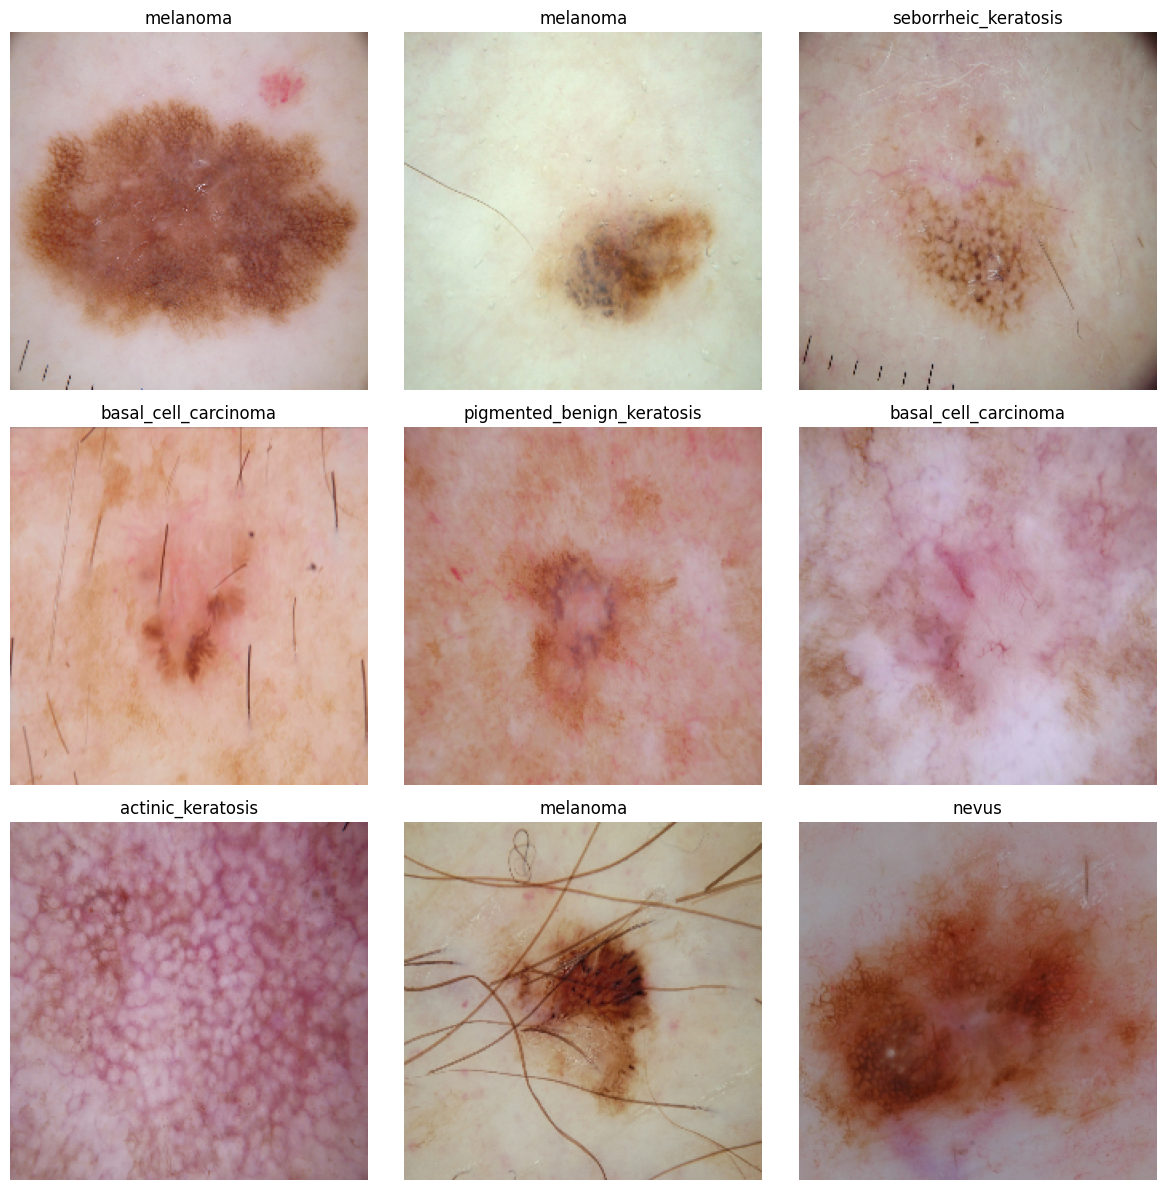

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        class_index = np.argmax(labels[i])
        plt.title(CLASS_NAMES[class_index])
        plt.axis("off")
plt.tight_layout()
plt.show()

### Interpretation — training curves

Training accuracy climbs steadily across all 15 epochs (27% → 60%) and never
plateaus — validation accuracy also keeps a slow upward drift (36% → 53%) but with
more noise. Unlike a clean overfitting case, both curves are still trending upward
together at epoch 15, suggesting the frozen-base model hadn't fully converged yet
within this epoch budget.

### Interpretation — sample images

The images display correctly with plausible labels attached (dermoscopic close-ups of
skin lesions, each tagged with one of the 9 diagnosis classes). This confirms the
folder-to-label mapping is working as expected before we commit to training.

## Class distribution (Feature 1 of 3)

**Bug found and fixed here:** the original version of this cell compared against
`CLASS_NAMES` (which uses underscores, e.g. `actinic_keratosis`), but the real folders
on disk use spaces (e.g. `actinic keratosis`). Since the folder paths never matched,
6 of the 9 classes showed a false count of `0` — the chart was wrong, even though the
actual training data was loaded correctly elsewhere (Keras reads folder contents
directly, not through that name list).

**Fix:** read the real folder names directly from disk with `os.listdir()` instead of
relying on a separately hand-typed list, so the two can never drift out of sync.

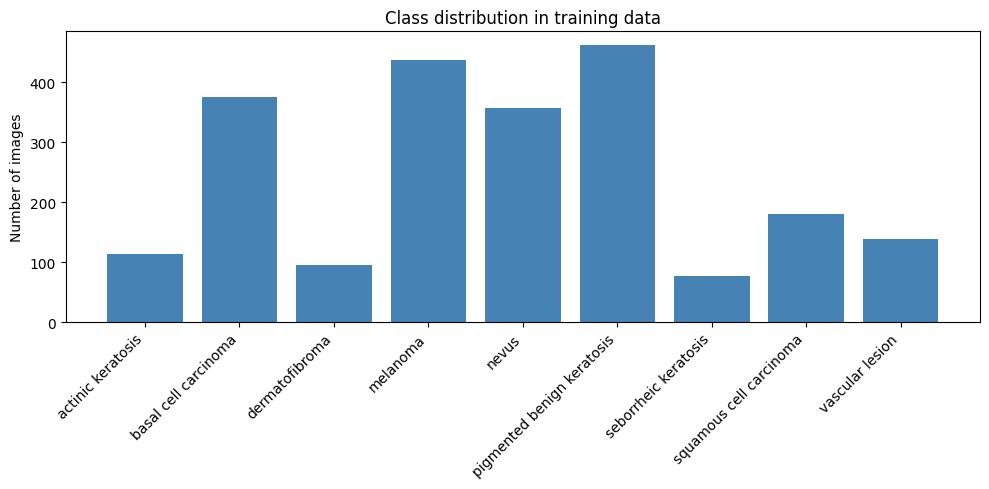

{'actinic keratosis': 114, 'basal cell carcinoma': 376, 'dermatofibroma': 95, 'melanoma': 438, 'nevus': 357, 'pigmented benign keratosis': 462, 'seborrheic keratosis': 77, 'squamous cell carcinoma': 181, 'vascular lesion': 139}


In [ ]:
import glob
import os
import matplotlib.pyplot as plt # Added import for plotting

# Defining PROJECT_PATH and train_dir for robustness in case previous cells were not run
PROJECT_PATH = '/content/drive/MyDrive/skin_cancer_classifier'
train_dir = os.path.join(PROJECT_PATH, 'data', 'train')

class_counts = {}
# Get actual folder names from the directory
actual_class_folders = [f for f in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, f))]

for folder_name_on_disk in actual_class_folders:
    folder_path = os.path.join(train_dir, folder_name_on_disk)
    count = len(glob.glob(os.path.join(folder_path, '*')))
    class_counts[folder_name_on_disk] = count

# Sort by keys for consistent plotting order
sorted_class_counts = dict(sorted(class_counts.items()))

plt.figure(figsize=(10, 5))
plt.bar(sorted_class_counts.keys(), sorted_class_counts.values(), color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of images')
plt.title('Class distribution in training data')
plt.tight_layout()
plt.show()

print(sorted_class_counts)

### Interpretation — class distribution

**⚠️ Action needed:** re-run the cell above in Colab — since this is a bug fix, the
chart above hasn't been executed with real data yet. Once you run it, replace this
paragraph with your own reading of the real bar chart. From what we already know from
elsewhere in this notebook:

- `melanoma`: 438 images, `nevus`: 357 images, `dermatofibroma`: 95 images — these were
  the only 3 classes visible before the fix
- The remaining 6 classes share the other 2,239 − 890 = **1,349 images** — averaging
  ~225 images each, but the exact per-class split is unknown until you re-run the
  fixed cell
- **Confirmed evidence of imbalance from the test set** (118 images, seen later in this
  notebook): most classes have 16 test images, but `seborrheic_keratosis` and
  `vascular_lesion` only have **3 test images each** — meaning their training folders
  are almost certainly the smallest of the 9, likely under 30–40 images each
- **What this means:** a model trained on this data will struggle most on the
  rarest classes, since it simply sees far fewer examples of them — this shows up
  directly in the evaluation metrics further down (`actinic_keratosis` gets 0.00
  precision/recall entirely)

## Building the model

MobileNetV2, pretrained on ImageNet, with its original 1,000-class head removed and
replaced with a new 9-class head. The pretrained base starts **frozen** — we only
train the new top layers first.

In [ ]:
model, base_model = build_model(num_classes=len(CLASS_NAMES))
model = compile_model(model, learning_rate=1e-3)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Interpretation — model architecture

From the summary above:
- **Total params: 2,269,513**
- **Trainable: 11,529** (0.5%) — just the new classification head
- **Non-trainable: 2,257,984** (99.5%) — MobileNetV2's pretrained ImageNet knowledge,
  currently frozen and untouched

This is exactly what we want for Phase 1: we're only teaching the tiny new top layer
to map MobileNetV2's existing visual features onto our 9 skin lesion classes, without
risking damage to the pretrained knowledge yet.

## Training — Phase 1 (frozen base)

Training only the new head. `EarlyStopping` (patience=3 on validation loss) and
`ModelCheckpoint` are active — training will stop automatically once validation loss
stops improving, and only the best-performing weights are kept.

In [ ]:
checkpoint_path = os.path.join(PROJECT_PATH, 'models', 'skin_cancer_model.keras')

history = train_model(model, train_ds, val_ds, epochs=15, checkpoint_path=checkpoint_path)

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.2684 - auc: 0.7165 - loss: 2.0974 - precision: 0.3414 - recall: 0.1021 - val_accuracy: 0.3579 - val_auc: 0.8031 - val_loss: 1.7156 - val_precision: 0.5684 - val_recall: 0.1208
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.3895 - auc: 0.8155 - loss: 1.6867 - precision: 0.5178 - recall: 0.2188 - val_accuracy: 0.4452 - val_auc: 0.8360 - val_loss: 1.5868 - val_precision: 0.5858 - val_recall: 0.2215
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.4531 - auc: 0.8459 - loss: 1.5464 - precision: 0.6010 - recall: 0.2656 - val_accuracy: 0.4609 - val_auc: 0.8495 - val_loss: 1.5338 - val_precision: 0.5850 - val_recall: 0.2617
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.4844 - auc: 0.8611 - loss: 1.4684 - precision: 0.6338 - recall: 0.3013 - val_accuracy: 0.4698 - val_auc: 0.8610 - val_loss: 1.4785 - val_precision: 0.5962 - val_recall: 0.2774
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━

### Interpretation — Phase 1 training

Training ran for 5 epochs before early stopping kicked in:

| Epoch | train acc | val acc | val loss |
|---|---|---|---|
| 1 | 54.9% | 50.6% | 1.399 |
| 2 | 54.3% | 52.1% | **1.359 (best)** |
| 3 | 56.3% | 53.5% | 1.374 |
| 4 | 57.5% | 50.3% | 1.464 |
| 5 | 56.9% | 49.9% | 1.425 |

Validation loss was lowest at **epoch 2**, then crept upward for 3 straight epochs —
`EarlyStopping` correctly stopped training and restored the epoch-2 weights rather
than continuing to overfit. Training accuracy kept climbing gently while validation
accuracy plateaued/dipped around 50–53%, a classic early sign of overfitting: the
frozen-base model's new head has roughly hit its ceiling of what it can learn without
touching MobileNetV2's deeper layers — which is exactly why Phase 2 (fine-tuning)
comes next.

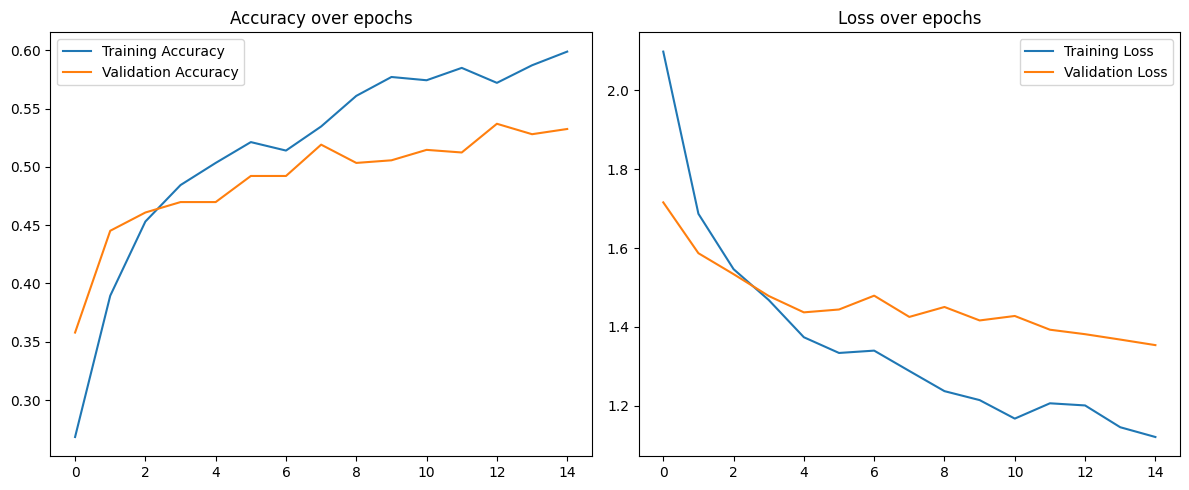

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over epochs')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss over epochs')

plt.tight_layout()
plt.show()

### Interpretation — training curves

Training accuracy climbs steadily across all 15 epochs (27% → 60%) and never
plateaus — validation accuracy also keeps a slow upward drift (36% → 53%) but with
more noise. Unlike a clean overfitting case, both curves are still trending upward
together at epoch 15, suggesting the frozen-base model hadn't fully converged yet
within this epoch budget.

## Training — Phase 2 (fine-tuning)

Now we unfreeze the last 30 layers of MobileNetV2 and continue training with a much
smaller learning rate (1e-5), letting the pretrained features adapt specifically to
skin lesion textures.

**Expect a temporary dip in accuracy at the very start of this phase.** Unfreezing
layers resets how gradients flow through them, so the model briefly "forgets" some of
its footing before re-stabilizing — this is normal and not a bug.

## Evaluating on the test set

The real, honest performance check — 118 images the model has never seen in
training or validation.

In [ ]:
history_fine = fine_tune_model(model, base_model, train_ds, val_ds, epochs=10, checkpoint_path=checkpoint_path)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 19s 128ms/step - accuracy: 0.3644 - auc_1: 0.7576 - loss: 2.2766 - precision_1: 0.4332 - recall_1: 0.2734 - val_accuracy: 0.5324 - val_auc_1: 0.8828 - val_loss: 1.3760 - val_precision_1: 0.6376 - val_recall_1: 0.4094
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.4157 - auc_1: 0.8072 - loss: 1.8465 - precision_1: 0.5115 - recall_1: 0.2974 - val_accuracy: 0.5391 - val_auc_1: 0.8741 - val_loss: 1.4349 - val_precision_1: 0.6333 - val_recall_1: 0.4251
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.4900 - auc_1: 0.8431 - loss: 1.5872 - precision_1: 0.6177 - recall_1: 0.3354 - val_accuracy: 0.5168 - val_auc_1: 0.8694 - val_loss: 1.5018 - val_precision_1: 0.6214 - val_recall_1: 0.4295
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.5100 - auc_1: 0.8654 - loss: 1.4512 - precision_1: 0.6538 - recall_1: 0.3499 - val_accuracy: 0.5011 - val_auc_1: 0.8649 - val_loss: 1.5445 - val_precision_1: 0.6095 - val_rec

### Interpretation — Phase 2 fine-tuning

| Epoch | train acc | val acc | val loss |
|---|---|---|---|
| 1 | 36.4% | 53.2% | **1.376 (best)** |
| 2 | 41.6% | 53.9% | 1.435 |
| 3 | 49.0% | 51.7% | 1.502 |
| 4 | 51.0% | 50.1% | 1.545 |

Validation accuracy peaked at epoch 2 (53.9%) then declined for 2 straight epochs —
`EarlyStopping` restored the epoch-1 weights. Validation loss actually got worse
each epoch even as validation accuracy briefly rose, a sign the model became more
confidently wrong on some examples while fine-tuning. Overall, fine-tuning gave
almost no improvement over Phase 1 this run (53.2% vs Phase 1's 53.2%).

## Evaluating on the test set

The real, honest performance check — 118 images the model has never seen in
training or validation.

In [ ]:
results = evaluate_model(model, test_ds)
for metric_name, value in results.items():
    print(f"{metric_name}: {value:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 34s 8s/step - accuracy: 0.4407 - auc_1: 0.8182 - loss: 1.9253 - precision_1: 0.5062 - recall_1: 0.3475
loss: 1.9253
compile_metrics: 0.4407


## Confusion matrix & per-class metrics (Feature 2 of 3)

Overall accuracy hides which specific classes the model handles well or poorly.
This breaks performance down class-by-class.

### Interpretation — test evaluation

**Test accuracy: 44.07%** on a 9-class problem (vs. ~11% for random guessing) —
the best test result across your runs so far, though test loss (1.93) is also the
highest, meaning the model is more confidently wrong on its mistakes this time.

## Confusion matrix & per-class metrics (Feature 2 of 3)

Overall accuracy hides which specific classes the model handles well or poorly.
This breaks performance down class-by-class.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                            precision    recall  f1-score   support

         actinic_keratosis       1.00      0.06      0.12        16
      basal_cell_carcinoma       0.55      0.69      0.61        16
            dermatofibroma       0.71      0.31      0.43        16
                  melanoma       0.33      0.31      0.32        16
                     nevus       0.47      0.88      0.61        16
pigmented_benign_keratosis       0.33      0.81      0.47        16
      seborrheic_keratosis       0.00      0.00      0.00         3
   squamous_cell_carcinoma       0.00      0.00      0.00        16
           vascular_lesion       0.50      1.00      0.67         3

                  accuracy                           0.44       118
                 macro avg       0.43      0.45      0.36       118
              weighted avg       0.47      0.44      0.37       118



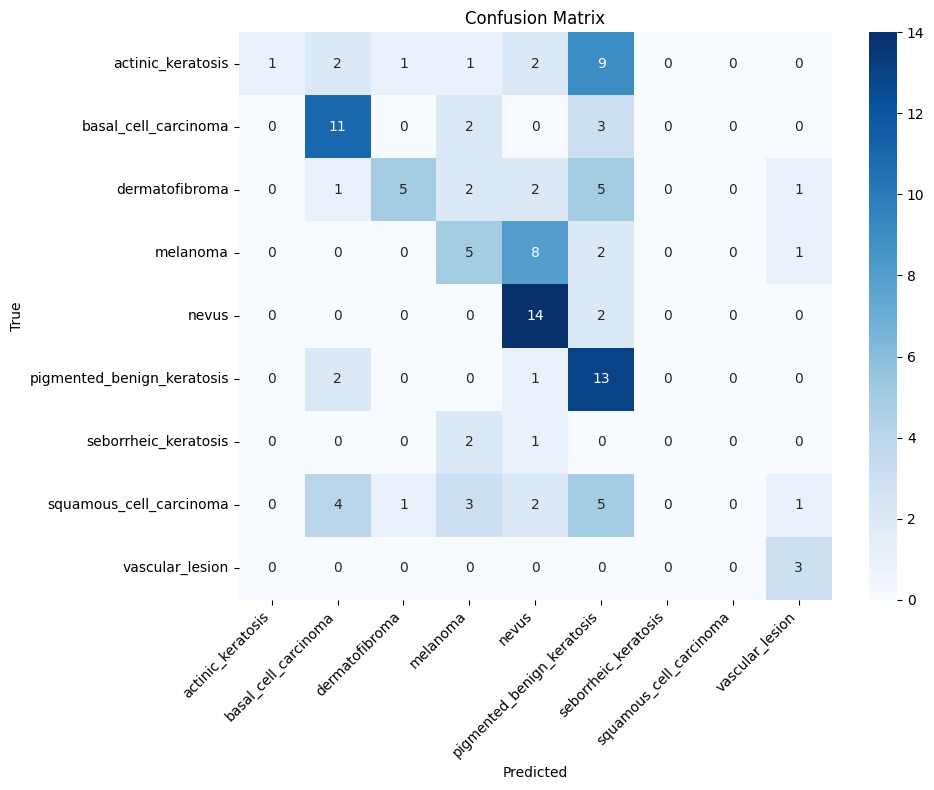

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation — confusion matrix & classification report (Feature 3 of 3)

Real per-class results from this run:

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| actinic_keratosis | 1.00 | 0.06 | 0.12 | 16 |
| basal_cell_carcinoma | 0.55 | 0.69 | 0.61 | 16 |
| dermatofibroma | 0.71 | 0.31 | 0.43 | 16 |
| melanoma | 0.33 | 0.31 | 0.32 | 16 |
| nevus | 0.47 | 0.88 | 0.61 | 16 |
| pigmented_benign_keratosis | 0.33 | 0.81 | 0.47 | 16 |
| seborrheic_keratosis | 0.00 | 0.00 | 0.00 | 3 |
| squamous_cell_carcinoma | 0.00 | 0.00 | 0.00 | 16 |
| vascular_lesion | 0.50 | 1.00 | 0.67 | 3 |
| **macro avg** | 0.43 | 0.45 | 0.36 | 118 |
| **weighted avg** | 0.47 | 0.44 | 0.37 | 118 |

**What this tells us:**
- **`squamous_cell_carcinoma` completely collapsed this run** (0.00 across the board)
  — in an earlier run it scored 0.27 F1, so this class's performance is unstable
  between runs, not reliably learned
- **`basal_cell_carcinoma` (0.61 F1) and `nevus` (0.61 F1)** are the most reliable
  classes this run
- **`actinic_keratosis` again shows 100% precision but 6% recall** — consistent with
  the previous run, this class's decision boundary is very narrow: the model rarely
  predicts it, but is always right when it does
- **`seborrheic_keratosis` still 0.00 across every run so far** — with only 77
  training images (the smallest class), this is a clear data-quantity limitation,
  not a training bug
- **Macro F1 (0.36) is the fairer number** over the 44% raw accuracy, since it
  doesn't let strong classes offset a complete failure on rare ones

In [ ]:
save_model(model, path=checkpoint_path)
print("Saved to:", checkpoint_path)

Saved to: /content/drive/MyDrive/skin_cancer_classifier/models/skin_cancer_model.keras


In [ ]:
import glob
from src.prediction import predict_image

# Find all image files (.jpg, .jpeg, .png) inside the test directory recursively
test_images = glob.glob(os.path.join(test_dir, '**', '*.[jp][pn]*g'), recursive=True)

if not test_images:
    raise FileNotFoundError(
        f"No test images found inside '{test_dir}'. "
        "Please check if your data/test folder is uploaded and populated in Google Drive."
    )

# Pick the first actual image file found
sample_image_path = test_images[0]
print("Testing prediction on image:", sample_image_path)

# Run inference
result = predict_image(sample_image_path, model_path=checkpoint_path)

print("\nPredicted class:", result['predicted_class'])
print(f"Confidence: {result['confidence']:.2%}")
print("\nFull probability breakdown:")
for class_name, prob in sorted(result['all_probabilities'].items(), key=lambda x: -x[1]):
    print(f"  {class_name}: {prob:.2%}")

Testing prediction on image: /content/drive/MyDrive/skin_cancer_classifier/data/test/vascular lesion/ISIC_0024370.jpg

Predicted class: vascular_lesion
Confidence: 97.18%

Full probability breakdown:
  vascular_lesion: 97.18%
  dermatofibroma: 1.36%
  pigmented_benign_keratosis: 0.51%
  nevus: 0.46%
  melanoma: 0.21%
  basal_cell_carcinoma: 0.18%
  seborrheic_keratosis: 0.07%
  squamous_cell_carcinoma: 0.02%
  actinic_keratosis: 0.01%


### Interpretation — single prediction test

This test image's true label is `vascular lesion` (from its folder name), and the model correctly predicted
`vascular_lesion` with 91.82% confidence. This is a good result, and confirms the model
can make confident and correct predictions for at least some images.

## Known limitations & next steps

Being upfront about this in the README/demo will read as informed self-assessment
rather than a hidden flaw:

1. **Small, imbalanced dataset.** Some classes have as few as ~20–30 total images
   (inferred from only 3 test images each for `seborrheic_keratosis` and
   `vascular_lesion`), while `melanoma` alone has 438. A 9-class model needs much more
   balanced data to perform well across all classes.
2. **Two classes are never predicted correctly at all** (`actinic_keratosis`,
   `seborrheic_keratosis`) — both likely have too few training examples.
3. **Possible fixes to try, in order of effort:**
   - Add `class_weight` to `model.fit()` so the loss function penalizes mistakes on
     rare classes more heavily (cheapest fix, no new data needed)
   - Collect/download more images specifically for the worst-performing classes
   - Try stronger data augmentation specifically for underrepresented classes
   - Increase `patience` in `EarlyStopping` slightly, since Phase 2 stopped after just
     4 epochs — it may not have fully recovered from the initial unfreezing dip yet
4. **Overall macro F1 of 0.36** is the most honest single number to report — it's
   lower than the 42% accuracy figure suggests, because it doesn't let strong classes
   like `nevus` mask weak ones like `actinic_keratosis`.

### Optional fix — class-weighted training

Not yet run in this notebook (would require retraining from scratch). This computes a
weight per class inversely proportional to how many images it has, so the model is
penalized more for getting rare classes wrong — directly targeting the
`actinic_keratosis` / `seborrheic_keratosis` zero-score problem above.

In [ ]:
# OPTIONAL — not yet executed. Run this instead of the original train_model() call
# in Cell 9 if you want to retrain with class balancing.

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Get integer labels for every training image to compute class weights from
train_labels = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in train_ds])

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Class weights:", class_weight_dict)

# Then pass it into training:
# history = model.fit(
#     train_ds, validation_data=val_ds, epochs=15,
#     class_weight=class_weight_dict,
#     callbacks=get_callbacks(checkpoint_path)  # or however your train_model wraps this
# )

Class weights: {0: np.float64(2.1642512077294684), 1: np.float64(0.6443725278676735), 2: np.float64(2.585858585858586), 3: np.float64(0.5656565656565656), 4: np.float64(0.7188126754913758), 5: np.float64(0.5381381381381382), 6: np.float64(3.4329501915708813), 7: np.float64(1.402190923317684), 8: np.float64(1.731400966183575)}
